In [2]:
# 1. ЗАГРУЗКА ДАННЫХ

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Настройка отображения
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("=" * 80)
print("АНАЛИЗ ДАННЫХ О ПРОДАЖАХ АВТОМОБИЛЕЙ")
print("=" * 80)

# 1. ЗАГРУЗКА ДАННЫХ
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 50)

df = pd.read_csv('car_prices.csv')
print(f"Данные успешно загружены!")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
print(df.head())

АНАЛИЗ ДАННЫХ О ПРОДАЖАХ АВТОМОБИЛЕЙ

1. ЗАГРУЗКА ДАННЫХ
--------------------------------------------------
Данные успешно загружены!
Размер датасета: 558837 строк, 16 столбцов

Первые 5 строк:
   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    264

In [ ]:
# 2. АНАЛИЗ СТРУКТУРЫ ДАННЫХ И ПРОПУСКОВ

In [4]:
print("\n2. АНАЛИЗ СТРУКТУРЫ ДАННЫХ И ПРОПУСКОВ")
print("-" * 50)

print("\nИнформация о датасете:")
print(df.info())

print("\nСтатистика пропущенных значений:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
    print(f"\nВсего пропущенных значений: {missing_data.sum()}")
else:
    print("Пропущенных значений нет")

print("\nСтатистика по числовым колонкам:")
print(df.describe())



2. АНАЛИЗ СТРУКТУРЫ ДАННЫХ И ПРОПУСКОВ
--------------------------------------------------

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 

In [ ]:
# 3. ОБРАБОТКА ДАННЫХ

In [5]:
print("\n3. ОБРАБОТКА ДАННЫХ")
print("-" * 50)


def prepare_data(df):
    """
    Подготовка данных для моделирования с обработкой ошибок и пропусков
    """
    data = df.copy()

    # Обработка даты продажи
    try:
        # Извлекаем только дату из строки
        data['saledate_clean'] = data['saledate'].astype(str).str.split().str[0]
        data['saledate_clean'] = pd.to_datetime(data['saledate_clean'], errors='coerce')

        # Создаем признаки из даты
        data['sale_year'] = data['saledate_clean'].dt.year
        data['sale_month'] = data['saledate_clean'].dt.month
        data['sale_day'] = data['saledate_clean'].dt.day
        data['sale_dayofweek'] = data['saledate_clean'].dt.dayofweek

        # Заполняем пропуски в датах
        data['sale_year'].fillna(2015, inplace=True)
        data['sale_month'].fillna(1, inplace=True)
        data['sale_day'].fillna(1, inplace=True)
        data['sale_dayofweek'].fillna(0, inplace=True)

        data['sale_year'] = data['sale_year'].astype(int)
        data['sale_month'] = data['sale_month'].astype(int)
        data['sale_day'] = data['sale_day'].astype(int)
        data['sale_dayofweek'] = data['sale_dayofweek'].astype(int)

    except Exception as e:
        print(f"Предупреждение при обработке даты: {e}")
        data['sale_year'] = 2015
        data['sale_month'] = 1
        data['sale_day'] = 1
        data['sale_dayofweek'] = 0

    # Создание признака "возраст автомобиля"
    data['car_age'] = data['sale_year'] - data['year']
    data['car_age'] = data['car_age'].clip(lower=0)

    # Создание признака "разница между MMR и ценой"
    data['mmr_difference'] = data['mmr'] - data['sellingprice']

    # Создание признака "пробег в год"
    data['mileage_per_year'] = data['odometer'] / (data['car_age'] + 1)
    data['mileage_per_year'] = data['mileage_per_year'].clip(upper=100000)
    data['mileage_per_year'] = data['mileage_per_year'].fillna(data['mileage_per_year'].median())

    # Заполнение пропусков в числовых колонках
    numeric_cols = ['condition', 'odometer']
    for col in numeric_cols:
        if col in data.columns:
            data[col] = data[col].replace([np.inf, -np.inf], np.nan)
            data[col].fillna(data[col].median(), inplace=True)

    # Заполнение пропусков в категориальных колонках
    categorical_cols = ['color', 'interior', 'trim', 'body', 'transmission', 'make', 'model', 'state']
    for col in categorical_cols:
        if col in data.columns:
            data[col].fillna('unknown', inplace=True)

    # Удаляем временные колонки
    if 'saledate_clean' in data.columns:
        data.drop('saledate_clean', axis=1, inplace=True)

    return data


# Применяем подготовку
df_processed = prepare_data(df)
print("Данные подготовлены!")
print(f"Новый размер датасета: {df_processed.shape}")
print(f"Кол-во пропусков после обработки: {df_processed.isnull().sum().sum()}")

print("\nНовые созданные признаки:")
new_features = ['sale_year', 'sale_month', 'sale_day', 'sale_dayofweek',
                'car_age', 'mmr_difference', 'mileage_per_year']
for feat in new_features:
    if feat in df_processed.columns:
        print(f"  - {feat}: {df_processed[feat].dtype}")



3. ОБРАБОТКА ДАННЫХ
--------------------------------------------------
Данные подготовлены!
Новый размер датасета: (558837, 23)
Кол-во пропусков после обработки: 104

Новые созданные признаки:
  - sale_year: int64
  - sale_month: int64
  - sale_day: int64
  - sale_dayofweek: int64
  - car_age: int64
  - mmr_difference: float64
  - mileage_per_year: float64


In [ ]:
# 4. МАТРИЦА КОРРЕЛЯЦИИ


4. МАТРИЦА КОРРЕЛЯЦИИ
--------------------------------------------------

Корреляция с целевой переменной 'sellingprice':
------------------------------------------------------------
Признак              Корреляция   Сила связи          
------------------------------------------------------------
mmr                  0.984        очень сильная       
year                 0.586        сильная             
condition            0.313        умеренная           
mmr_difference       -0.130       слабая              
mileage_per_year     -0.217       слабая              
odometer             -0.582       сильная             
car_age              -0.586       сильная             
sale_year            nan          очень слабая        
sale_month           nan          очень слабая        
sale_day             nan          очень слабая        
sale_dayofweek       nan          очень слабая        

Признаки с сильной и очень сильной связью (4):
  - mmr
  - year
  - odometer
  - car_age


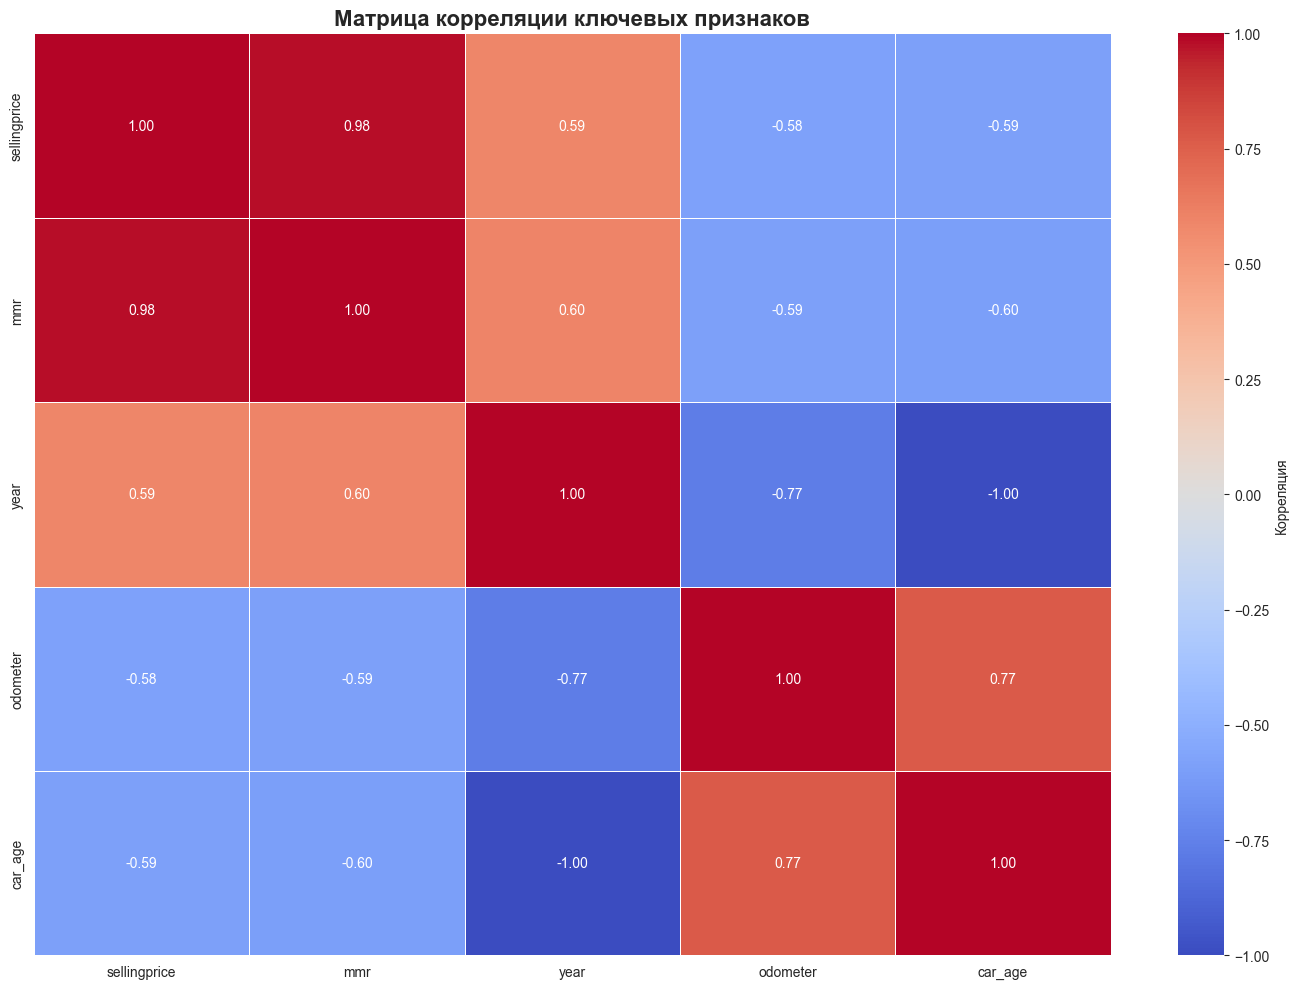

In [6]:
print("\n4. МАТРИЦА КОРРЕЛЯЦИИ")
print("-" * 50)

# Выбор числовых колонок
numeric_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice',
                'sale_year', 'sale_month', 'sale_day', 'sale_dayofweek',
                'car_age', 'mmr_difference', 'mileage_per_year']

# Проверяем наличие колонок
available_numeric = [col for col in numeric_cols if col in df_processed.columns]
correlation_matrix = df_processed[available_numeric].corr()

# Корреляция с целевой переменной
target_corr = correlation_matrix['sellingprice'].sort_values(ascending=False)
print("\nКорреляция с целевой переменной 'sellingprice':")
print("-" * 60)
print(f"{'Признак':<20} {'Корреляция':<12} {'Сила связи':<20}")
print("-" * 60)

# Классификация силы связи
strong_features = []
for feature, corr in target_corr.items():
    if feature != 'sellingprice':
        abs_corr = abs(corr)
        if abs_corr > 0.7:
            strength = "очень сильная"
            strong_features.append(feature)
        elif abs_corr > 0.5:
            strength = "сильная"
            strong_features.append(feature)
        elif abs_corr > 0.3:
            strength = "умеренная"
        elif abs_corr > 0.1:
            strength = "слабая"
        else:
            strength = "очень слабая"

        print(f"{feature:<20} {corr:<12.3f} {strength:<20}")

print(f"\nПризнаки с сильной и очень сильной связью ({len(strong_features)}):")
for feat in strong_features[:10]:
    print(f"  - {feat}")

# Построение тепловой карты
plt.figure(figsize=(14, 10))
features_for_heatmap = ['sellingprice'] + strong_features[:9]  # Ограничиваем до 10
available_for_heatmap = [f for f in features_for_heatmap if f in correlation_matrix.index]

sns.heatmap(correlation_matrix.loc[available_for_heatmap, available_for_heatmap],
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Корреляция'})
plt.title('Матрица корреляции ключевых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# 5. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

In [7]:
print("\n5. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("-" * 50)

# Выбираем важные категориальные признаки
important_categorical = ['make', 'model', 'body', 'transmission', 'state']


def encode_top_categories(df, column, top_n=15):
    """Кодирует только топ-N самых частых категорий"""
    if column not in df.columns:
        return pd.Series([0] * len(df))

    top_values = df[column].value_counts().nlargest(min(top_n, df[column].nunique())).index
    return df[column].apply(lambda x: x if x in top_values else 'other')


for col in important_categorical:
    if col in df_processed.columns:
        # Ограничиваем количество категорий
        df_processed[col + '_top'] = encode_top_categories(df_processed, col, top_n=15)

        # Кодируем
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col + '_top'].astype(str))

        print(f"{col}: {df_processed[col].nunique()} -> {df_processed[col + '_top'].nunique()} категорий")



5. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
--------------------------------------------------
make: 97 -> 16 категорий
model: 974 -> 16 категорий
body: 88 -> 16 категорий
transmission: 5 -> 5 категорий
state: 64 -> 16 категорий


In [ ]:
# 6. ПОДГОТОВКА ПРИЗНАКОВ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

In [8]:
print("\n6. ПОДГОТОВКА ПРИЗНАКОВ")
print("-" * 50)

# Выбор признаков для моделирования
feature_cols = strong_features.copy()  # Берем признаки с сильной корреляцией

# Добавляем дополнительные признаки
additional_features = ['mileage_per_year', 'sale_month']
for feat in additional_features:
    if feat in df_processed.columns and feat not in feature_cols:
        feature_cols.append(feat)

# Добавляем закодированные категориальные признаки
encoded_features = [col for col in df_processed.columns if col.endswith('_encoded')]
feature_cols.extend(encoded_features)

# Убеждаемся, что все признаки есть в данных
feature_cols = [col for col in feature_cols if col in df_processed.columns]
print(f"Выбрано признаков для моделирования: {len(feature_cols)}")
print(f"Первые 10 признаков: {feature_cols[:10]}")

X = df_processed[feature_cols].copy()
y = df_processed['sellingprice'].copy()

# Проверка на NaN и inf
print(f"\nПроверка NaN в признаках: {X.isnull().sum().sum()}")
print(f"Проверка inf в признаках: {np.isinf(X).sum().sum()}")

# Заменяем inf на NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Используем SimpleImputer для заполнения NaN
imputer = SimpleImputer(strategy='median')
X_imputed_array = imputer.fit_transform(X)

# Создаем DataFrame с правильными колонками
X_imputed = pd.DataFrame(
    X_imputed_array,
    columns=X.columns,
    index=X.index
)

print(f"Проверка NaN после обработки: {X_imputed.isnull().sum().sum()}")

# Обработка выбросов в целевой переменной
q1 = y.quantile(0.01)
q99 = y.quantile(0.99)
mask = (y >= q1) & (y <= q99)
X_clean = X_imputed[mask]
y_clean = y[mask]

print(f"\nРазмер данных после удаления выбросов: {X_clean.shape}")
print(f"Диапазон цен: ${y_clean.min():,.0f} - ${y_clean.max():,.0f}")
print(f"Средняя цена: ${y_clean.mean():,.0f}")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



6. ПОДГОТОВКА ПРИЗНАКОВ
--------------------------------------------------
Выбрано признаков для моделирования: 11
Первые 10 признаков: ['mmr', 'year', 'odometer', 'car_age', 'mileage_per_year', 'sale_month', 'make_encoded', 'model_encoded', 'body_encoded', 'transmission_encoded']

Проверка NaN в признаках: 38
Проверка inf в признаках: 0
Проверка NaN после обработки: 0

Размер данных после удаления выбросов: (547909, 11)
Диапазон цен: $500 - $44,900
Средняя цена: $13,284

Размер обучающей выборки: (438327, 11)
Размер тестовой выборки: (109582, 11)


In [ ]:
# 7. ОБУЧЕНИЕ МОДЕЛЕЙ

In [9]:
print("\n7. ОБУЧЕНИЕ МОДЕЛЕЙ")
print("=" * 80)


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Оценка модели регрессии
    """
    try:
        # Обучение
        model.fit(X_train, y_train)

        # Предсказания
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Метрики
        metrics = {
            'Model': model_name,
            'R2_Train': r2_score(y_train, y_train_pred),
            'R2_Test': r2_score(y_test, y_test_pred),
            'MAE': mean_absolute_error(y_test, y_test_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'MAPE': np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
        }

        # Cross-validation (на уменьшенной выборке для скорости)
        sample_size = min(10000, len(X_train))
        cv_scores = cross_val_score(model, X_train[:sample_size], y_train[:sample_size],
                                    cv=3, scoring='r2')
        metrics['CV_R2_Mean'] = cv_scores.mean()
        metrics['CV_R2_Std'] = cv_scores.std()

        return metrics, y_test_pred
    except Exception as e:
        print(f"  Ошибка при обучении {model_name}: {e}")
        return None, None


# Список 5 основных моделей
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge(alpha=1.0)),
    ('Lasso Regression', Lasso(alpha=1.0, max_iter=10000)),
    ('Decision Tree', DecisionTreeRegressor(max_depth=15, min_samples_split=10,
                                            min_samples_leaf=5, random_state=42)),
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=20,
                                            min_samples_split=5, n_jobs=-1, random_state=42))
]

# Обучение всех моделей
results = []
predictions = {}

for name, model in models:
    print(f"\nМодель: {name}")
    print("-" * 50)

    result = evaluate_model(model, X_train_scaled, X_test_scaled,
                            y_train, y_test, name)

    if result[0] is not None:
        metrics, preds = result
        results.append(metrics)
        predictions[name] = preds

        print(f"  R² (обучение): {metrics['R2_Train']:.4f}")
        print(f"  R² (тест): {metrics['R2_Test']:.4f}")
        print(f"  MAE: ${metrics['MAE']:,.2f}")
        print(f"  RMSE: ${metrics['RMSE']:,.2f}")
        print(f"  MAPE: {metrics['MAPE']:.2f}%")
        print(f"  CV R²: {metrics['CV_R2_Mean']:.4f} ± {metrics['CV_R2_Std']:.4f}")


7. ОБУЧЕНИЕ МОДЕЛЕЙ

Модель: Linear Regression
--------------------------------------------------
  R² (обучение): 0.9604
  R² (тест): 0.9619
  MAE: $1,074.73
  RMSE: $1,652.93
  MAPE: 15.35%
  CV R²: 0.9565 ± 0.0042

Модель: Ridge Regression
--------------------------------------------------
  R² (обучение): 0.9604
  R² (тест): 0.9619
  MAE: $1,074.73
  RMSE: $1,652.93
  MAPE: 15.35%
  CV R²: 0.9565 ± 0.0042

Модель: Lasso Regression
--------------------------------------------------
  R² (обучение): 0.9604
  R² (тест): 0.9619
  MAE: $1,074.66
  RMSE: $1,652.95
  MAPE: 15.34%
  CV R²: 0.9565 ± 0.0042

Модель: Decision Tree
--------------------------------------------------
  R² (обучение): 0.9675
  R² (тест): 0.9612
  MAE: $1,098.93
  RMSE: $1,667.55
  MAPE: 14.96%
  CV R²: 0.9418 ± 0.0042

Модель: Random Forest
--------------------------------------------------
  R² (обучение): 0.9793
  R² (тест): 0.9640
  MAE: $1,060.11
  RMSE: $1,605.70
  MAPE: 14.55%
  CV R²: 0.9543 ± 0.0029


In [ ]:
# 8. СРАВНЕНИЕ МЕТРИК


8. СРАВНЕНИЕ МЕТРИК

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК АЛГОРИТМОВ

               Модель  R² (обучение)  R² (тест)    MAE ($)   RMSE ($)  MAPE (%)  CV R² (средн.)
1      Random Forest         0.9793     0.9640  1060.1081  1605.6950   14.5471          0.9543
2  Linear Regression         0.9604     0.9619  1074.7320  1652.9253   15.3502          0.9565
3   Ridge Regression         0.9604     0.9619  1074.7322  1652.9255   15.3502          0.9565
4   Lasso Regression         0.9604     0.9619  1074.6587  1652.9537   15.3418          0.9565
5      Decision Tree         0.9675     0.9612  1098.9295  1667.5539   14.9643          0.9418


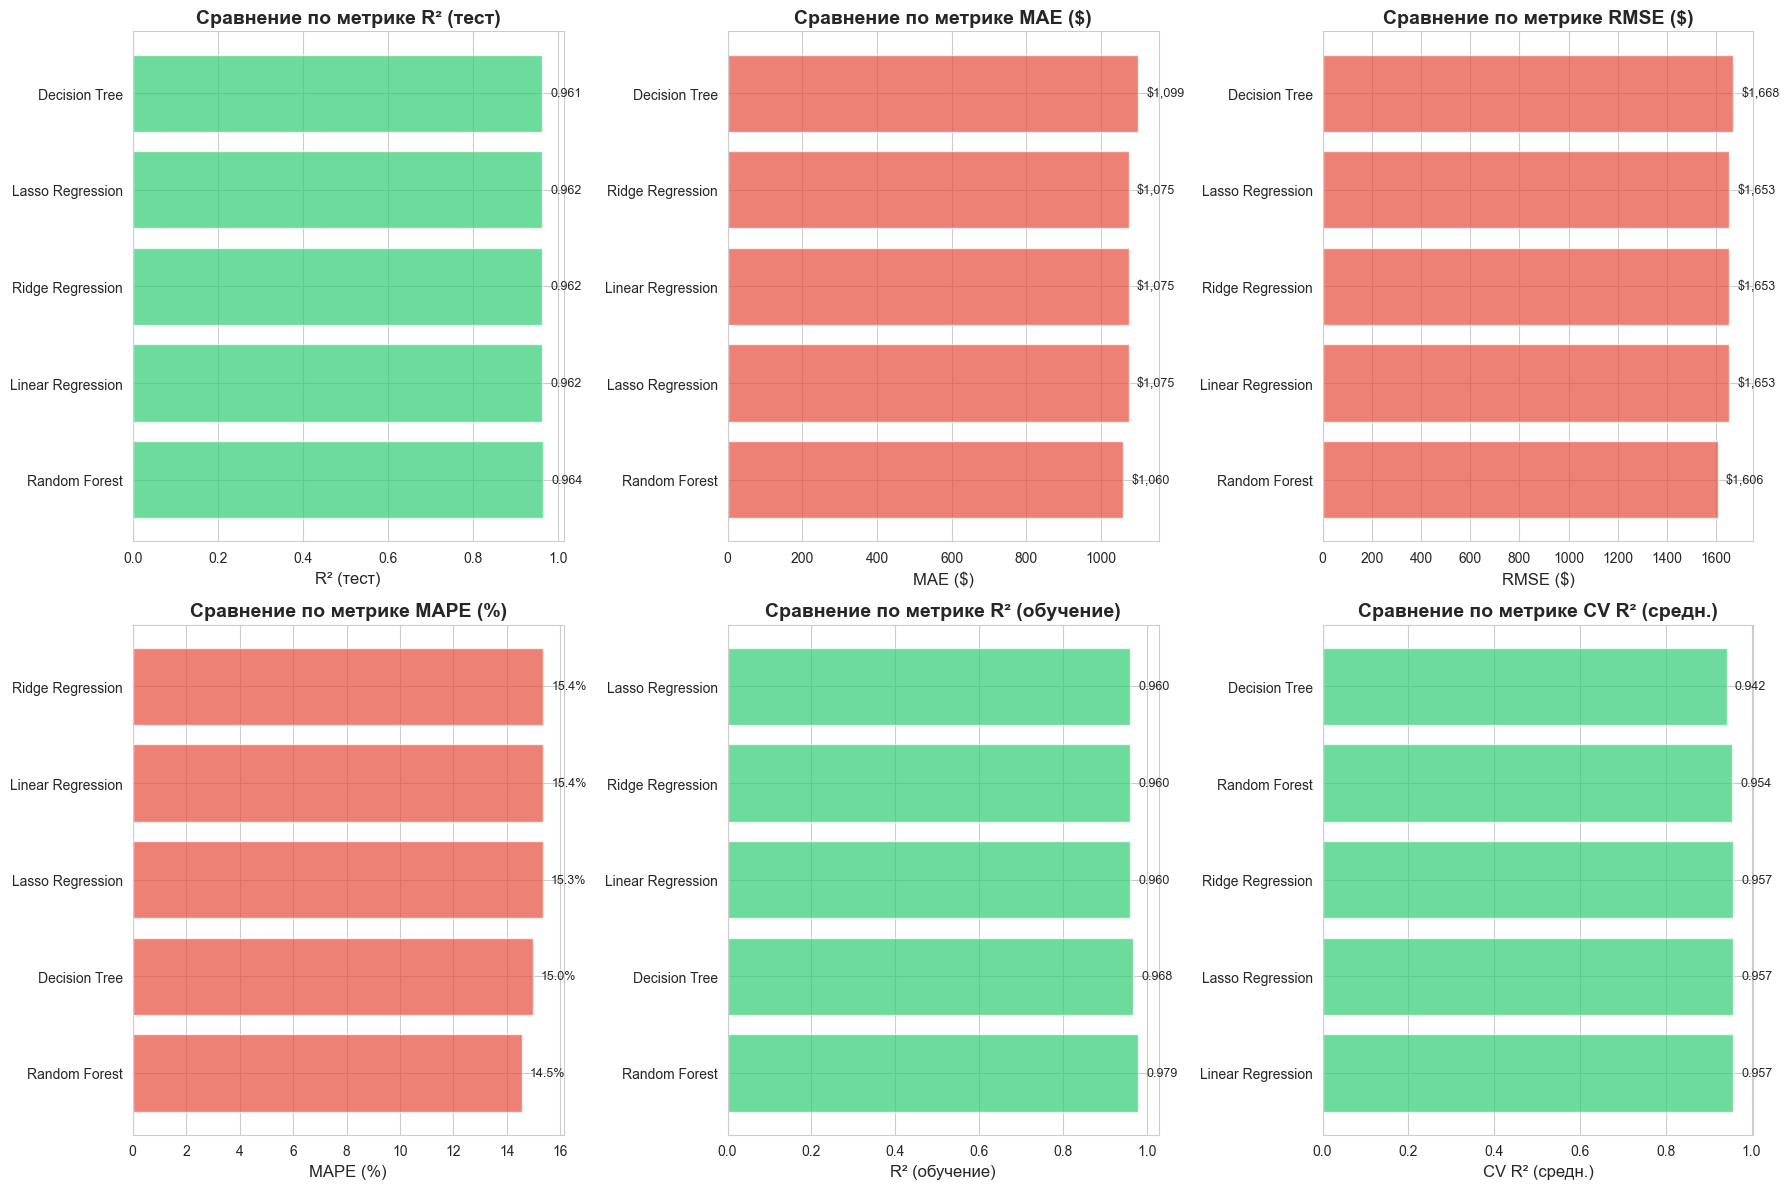

In [10]:
print("\n8. СРАВНЕНИЕ МЕТРИК")
print("=" * 80)

if results:
    results_df = pd.DataFrame(results)
    results_df = results_df.round(4)

    print("\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК АЛГОРИТМОВ")
    print("=" * 100)

    display_df = results_df[['Model', 'R2_Train', 'R2_Test', 'MAE', 'RMSE', 'MAPE', 'CV_R2_Mean']].copy()
    display_df.columns = ['Модель', 'R² (обучение)', 'R² (тест)', 'MAE ($)', 'RMSE ($)', 'MAPE (%)', 'CV R² (средн.)']

    display_df = display_df.sort_values('R² (тест)', ascending=False).reset_index(drop=True)
    display_df.index = range(1, len(display_df) + 1)

    print("\n", display_df.to_string())

    # Визуализация сравнения
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    metrics_to_plot = ['R² (тест)', 'MAE ($)', 'RMSE ($)', 'MAPE (%)', 'R² (обучение)', 'CV R² (средн.)']

    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]

        sorted_df = display_df.sort_values(metric, ascending=(metric in ['MAE ($)', 'RMSE ($)', 'MAPE (%)']))
        color = '#e74c3c' if metric in ['MAE ($)', 'RMSE ($)', 'MAPE (%)'] else '#2ecc71'

        bars = ax.barh(range(len(sorted_df)), sorted_df[metric].values, color=color, alpha=0.7)
        ax.set_yticks(range(len(sorted_df)))
        ax.set_yticklabels(sorted_df['Модель'].values, fontsize=10)
        ax.set_xlabel(metric, fontsize=12)
        ax.set_title(f'Сравнение по метрике {metric}', fontsize=14, fontweight='bold')

        # Добавление значений
        for i, (bar, val) in enumerate(zip(bars, sorted_df[metric].values)):
            if metric in ['MAE ($)', 'RMSE ($)']:
                text = f'${val:,.0f}'
            elif metric == 'MAPE (%)':
                text = f'{val:.1f}%'
            else:
                text = f'{val:.3f}'
            ax.text(val + (val * 0.02), bar.get_y() + bar.get_height() / 2, text,
                    va='center', fontsize=9)

    plt.tight_layout()
    plt.show()